In [2]:
from cirq_sic import *
np.set_printoptions(precision=3)

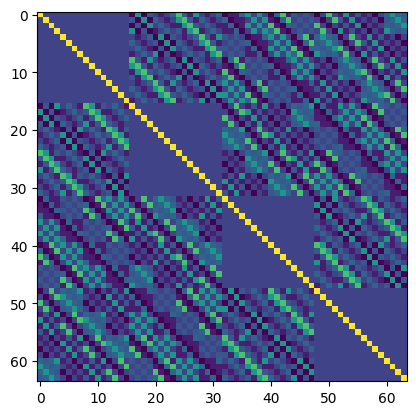

In [3]:
def tavakoli_displacements():
    d = 4
    X = np.exp(1j*np.pi/4)*np.array([[0, 1j, 0, 0],[-1, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1j, 0]])
    Z = np.exp(1j*np.pi/4)*np.array([[0, 0, -1, 0], [0, 0, 0, 1], [1j, 0, 0, 0], [0, 1j, 0, 0]])
    return np.array([[np.linalg.matrix_power(X, j) @ np.linalg.matrix_power(Z, k) for k in range(d)] for j in range(d)])

def tavakoli_construction():
    d = 4
    U = np.array([[0,0,1,0],[0,0,0,1j],[1,0,0,0],[0,-1j,0,0]])
    V = np.array([[0,1,0,0],[1,0,0,0],[0,0,0,-1j],[0,0,1j,0]])
    t = np.sqrt(2 + np.sqrt(5))
    n = np.sqrt(5 + np.sqrt(5))
    phi1 = np.array([t, 1j, 1j, 1j])/n
    fiducials = np.array([phi1, U @ phi1, V @ phi1, U @ V @ phi1])
    TD = tavakoli_displacements().reshape(d**2, d, d)
    csic = np.array([[O @ phi for O in TD] for phi in fiducials])
    return csic

d = 4
tavakoli = tavakoli_construction()
R1 = tavakoli.reshape(d**3, d)
G1 = abs(R1 @ R1.conj().T).real**2
plt.imshow(G1)

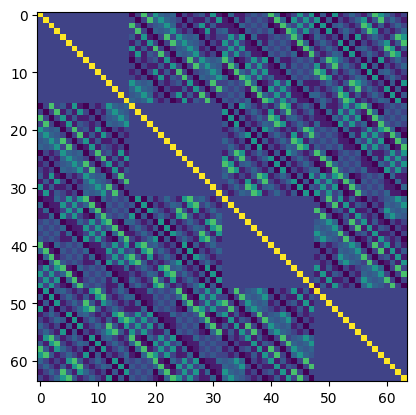

In [4]:
def sachin_construction():
    d = 4
    a = np.sqrt(2 + np.sqrt(5))
    b = np.sqrt((1-1/np.sqrt(5))/8)
    A = np.array([[1, -1, a, -1],
                [1j*a, 1j, -1j, -1j],
                [1, -1, a, -1],
                [-1j*a, -1j, 1j, 1j]]).T
    B = np.array([[1, -a, -1, 1],
                [1j, 1j, 1j, 1j*a],
                [-1, a, 1, -1],
                [1j, 1j, 1j, 1j*a]]).T
    fiducials = b*(np.exp(1j*np.pi/4)*A + B)
    
    D = wh_operators(d)["D"].reshape(d**2, d, d)
    csic = np.array([[O @ phi for O in D] for phi in fiducials])
    return csic

d = 4
sachin = sachin_construction()
R2 = sachin.reshape(d**3, d)
G2 = abs(R2 @ R2.conj().T).real**2
plt.imshow(G2)

In [5]:
def compound_plot(basis, N=75, alpha=2, cutoff=50, levels=10, filename="compound_plot.pdf"):
    thetas = np.linspace(0, np.pi, N)
    phis = np.linspace(0, 2*np.pi, N)

    # Build the full theta-phi fiducial grid in one shot.
    theta_grid = thetas[:, None]
    phi_grid = phis[None, :]
    fids = (
        np.cos(theta_grid / 2)[..., None] * basis[0]
        + np.exp(1j * phi_grid)[..., None] * np.sin(theta_grid / 2)[..., None] * basis[1]
    )

    # For rank-1 POVM elements E_a = |psi_a><psi_a| / d, the conditional matrix is
    # P_ab = Tr(E_a E_b) / Tr(E_b) = |<psi_a|psi_b>|^2 / d.
    D = wh_operators(d)["D"].reshape(d**2, d, d)
    #D = tavakoli_displacements().reshape(d**2, d, d)
    orbit_states = np.einsum("aij,tpj->tpai", D, fids, optimize=True)
    overlaps = np.einsum("tpai,tpbi->tpab", orbit_states.conj(), orbit_states, optimize=True)
    P = (np.abs(overlaps) ** 2 / d).real

    exact_magic = (1 / (1 - alpha)) * np.log(np.sum(P[..., :, 0] ** alpha, axis=-1)) - np.log(d)
    exact_deform = np.linalg.norm(np.linalg.pinv(P) - np.eye(d**2), axis=(-2, -1))

    max_magic = (1 / ( 1 - alpha)) * np.log((1+(d-1)*(d+1)**( 1 - alpha)) / d)
    sic_quantumness = np.linalg.norm(np.linalg.inv(SIC_P(d)) - np.eye(d**2))

    Theta, Phi = np.meshgrid(thetas, phis)
    fig, (ax1, ax2), = plt.subplots(1, 2, figsize=(12,6))

    cs_magic = ax1.contourf(Theta, Phi, exact_magic.T, levels=levels)
    #cs_magic = ax1.pcolormesh(Theta, Phi, exact_magic.T, edgecolors="none", shading="gouraud")
    fig.colorbar(cs_magic)

    ax1.set_title("%d-Renyi SE (SIC: %.3f)" % (alpha, max_magic))
    ax1.set_xlabel(r"$\theta$")
    ax1.set_ylabel(r"$\phi$")

    exact_deform_mat = exact_deform.copy()
    exact_deform_mat[exact_deform_mat > cutoff] = cutoff

    cs_deform = ax2.contourf(Theta, Phi, exact_deform_mat.T, levels=levels)
    #cs_deform = ax2.pcolormesh(Theta, Phi, exact_deform_mat.T, edgecolors="none", shading="gouraud")
    fig.colorbar(cs_deform)

    ax2.set_title("LTP deformation (SIC: %.3f)" % (sic_quantumness))
    ax2.set_xlabel(r"$\theta$")
    ax2.set_ylabel(r"$\phi$")
    fig.savefig(filename)

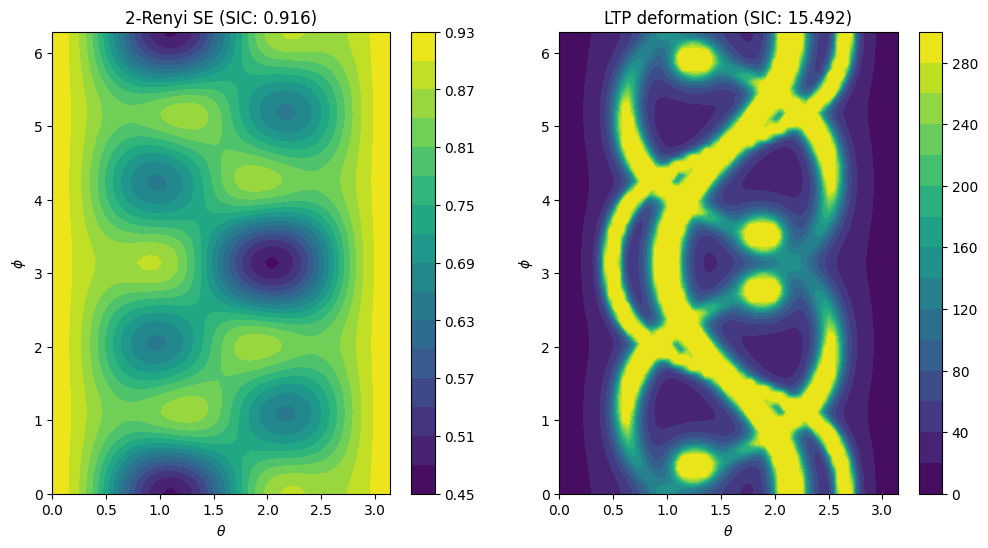

In [6]:
compound_plot([sachin[0][0], sachin[1][0]], N=75, cutoff=300, levels=15, filename="test.pdf")

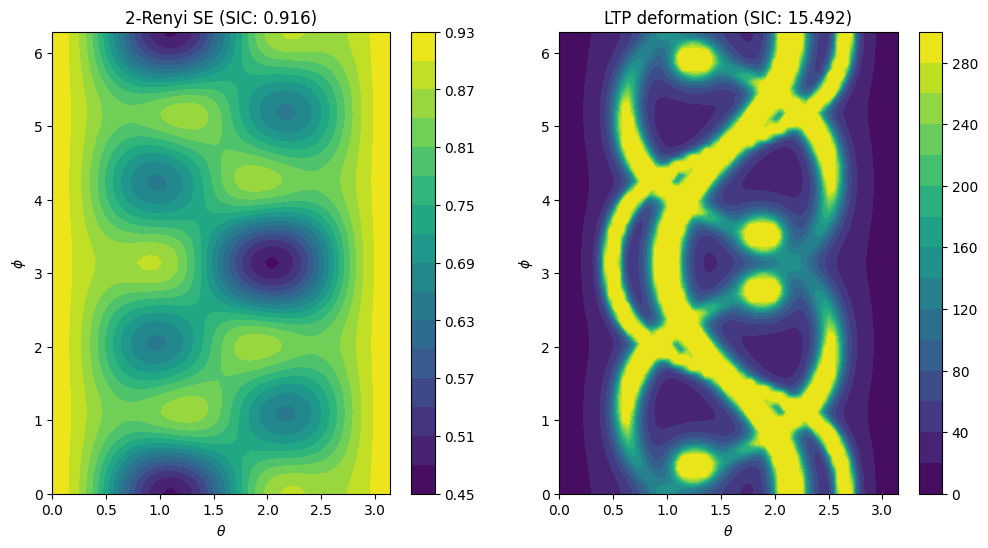

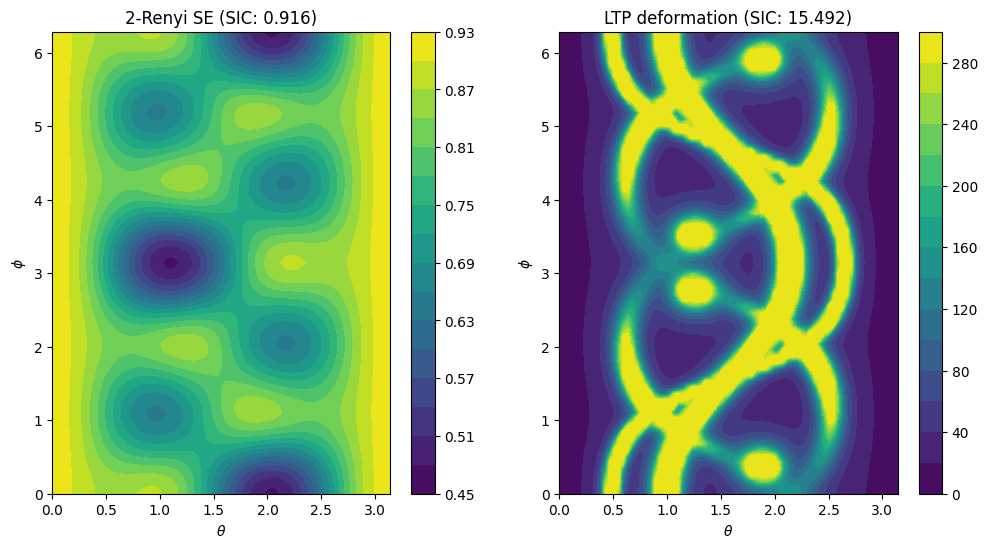

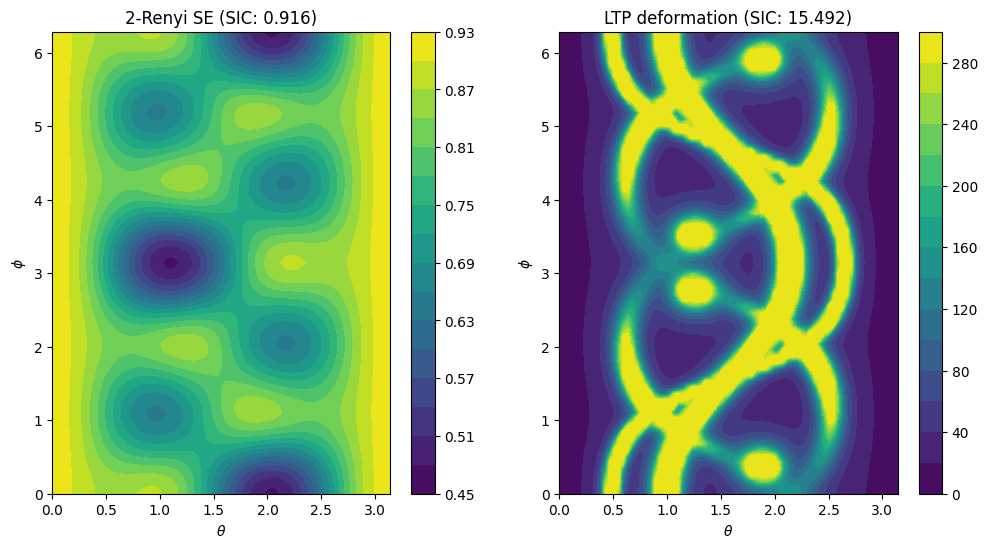

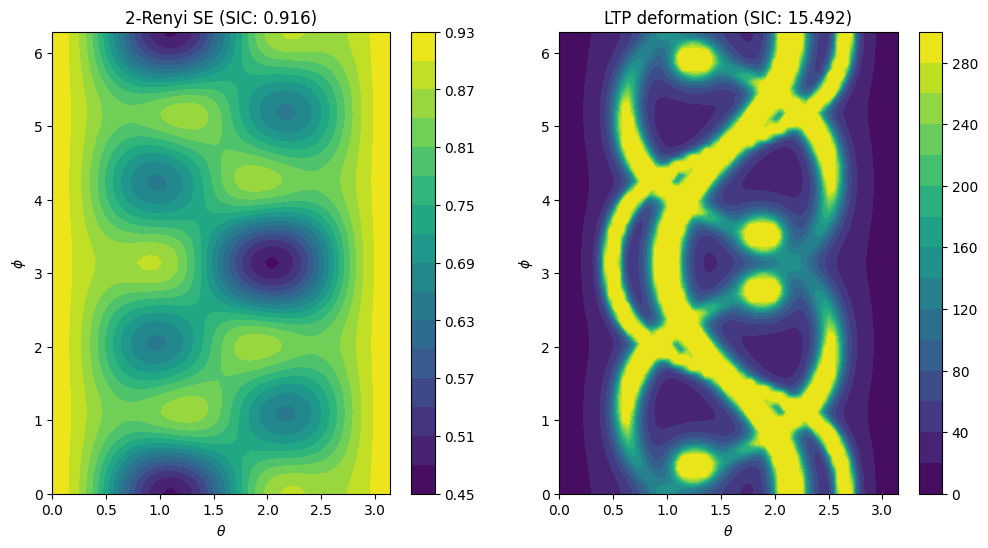

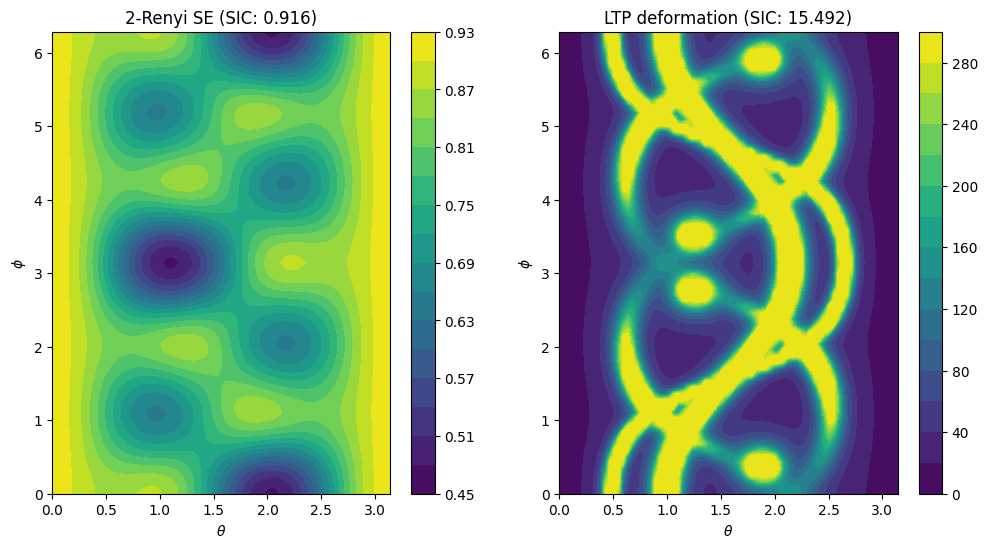

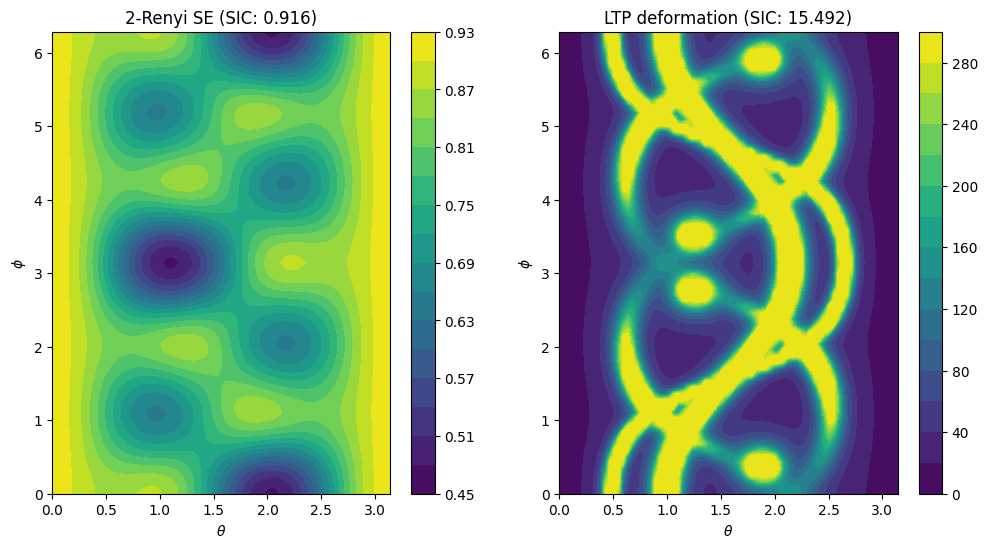

In [7]:
for i in range(d):
    for j in range(d):
        if i < j:
            #for k in range(d**2):
            k = 0
            compound_plot([sachin[i][k], sachin[j][k]],  N=75, cutoff=300, levels=15, filename="cmp_img/d4_sachin_%d_%d_%d.pdf" % (i,j, k))

## Tavakoli

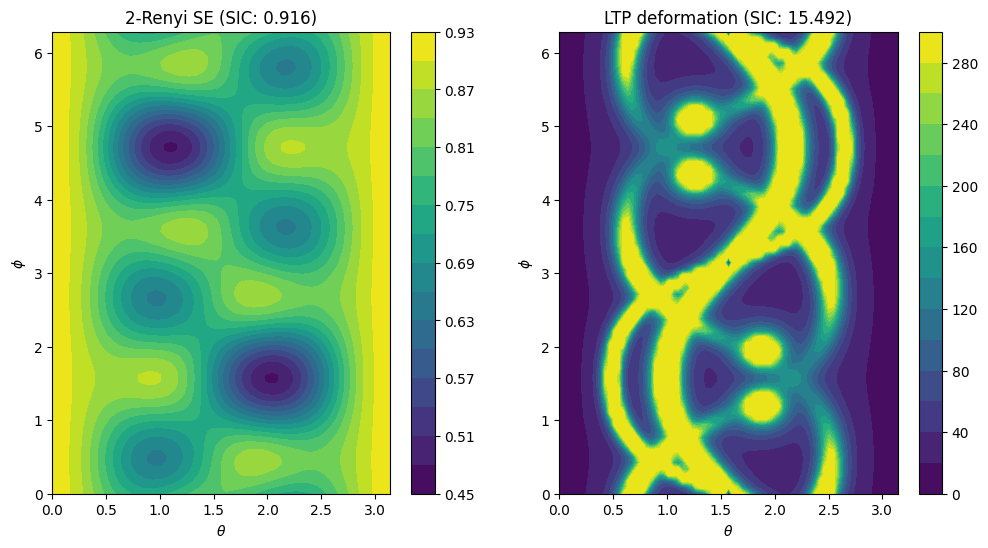

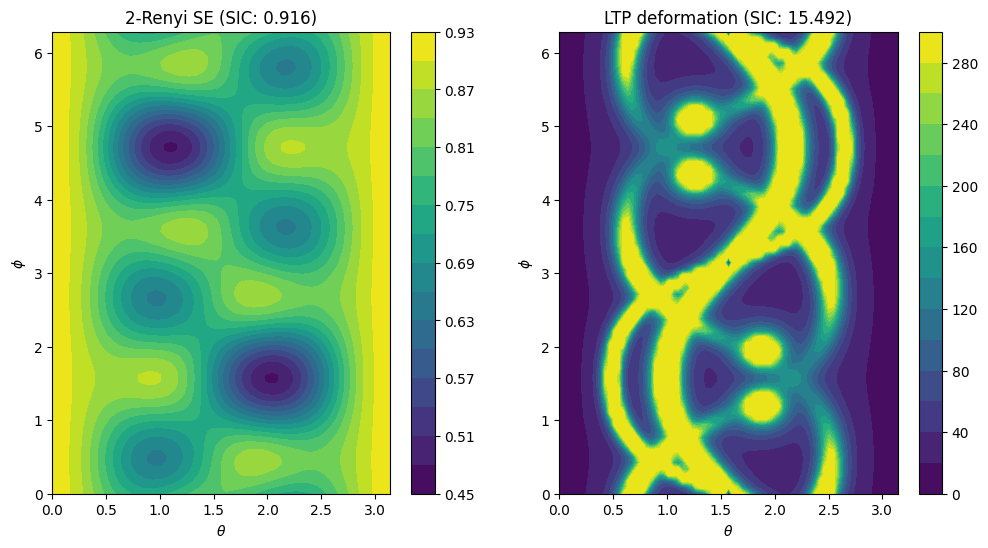

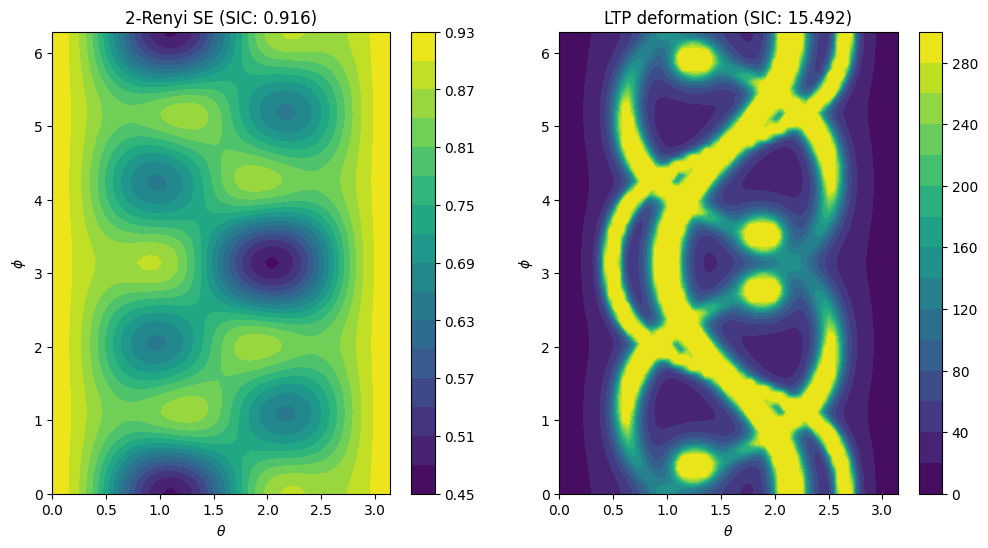

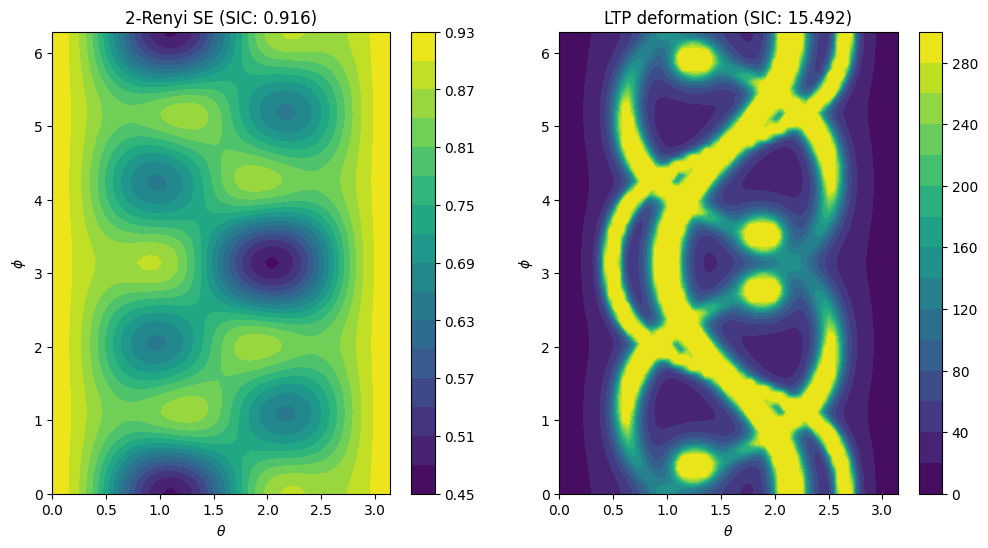

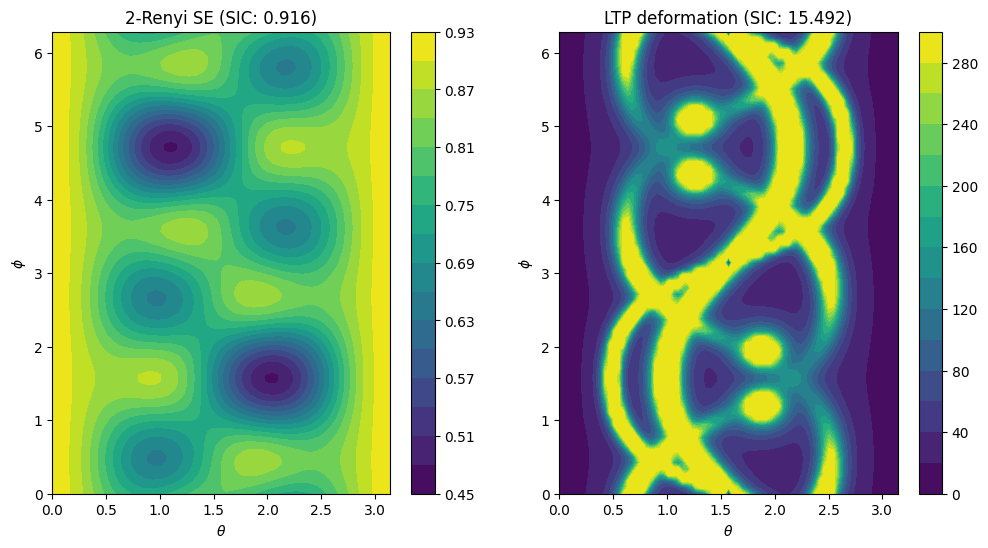

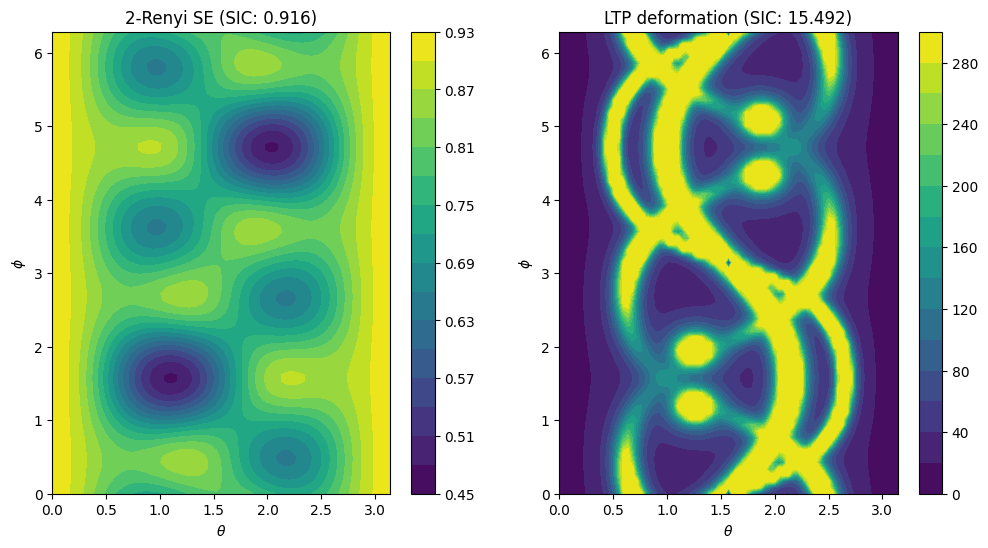

In [34]:
for i in range(d):
    for j in range(d):
        if i < j:
            compound_plot([tavakoli[i][0], tavakoli[j][0]],  N=75, cutoff=300, levels=15, filename="cmp_img/d4_tavakoli_%d_%d.pdf" % (i,j))